# Expert Validation — Multi-Expert, Multi-Condition

Methodologically rigorous validation of all four SAC experts under three
distinct evaluation conditions, each designed to answer a specific
question about the saved model:

| Condition       | `p_static` | `target_v_max` | Question it answers                                                              |
|-----------------|:---------:|:--------------:|----------------------------------------------------------------------------------|
| **matched**     |   0.30    |     0.50       | Is the saved checkpoint truly the best the training produced? (= training mix)   |
| **pure_dyn**    |   0.00    |     0.50       | How well does the agent track a moving target? (pure dynamic stress test)        |
| **pure_static** |   1.00    |     0.50       | How well does it hold position on random static targets? (pure hold stress test) |

Plus an **optional spatial diagnostic** on 9 hand-picked fixed positions —
useful for spotting workspace dead zones, *not* for measuring overall
performance.

> **Note on `matched`**: it's directly comparable to the training-time
> best only if the `EvalCallback` was run on the same distribution
> (`p_static=0.30`). If the EvalCallback used a different fixed
> condition (e.g. v=0.50 with p_static=0), change the parameters of
> `matched` below to replicate that condition.

Output is organized under `Evaluation/`:
- `<expert>/<condition>/{step_data.csv, per_episode.csv, summary.json}` — raw + aggregate per (expert, condition)
- `<expert>/static_diagnostic/...` — only if `RUN_STATIC_DIAGNOSTIC=True`
- `_crossexpert/summary_table.csv` — cross-expert aggregate
- `_crossexpert/*.png` — cross-expert plots
- `<INSPECT_EXPERT>/_figures/` — deep dive for the selected expert


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import json
import pickle
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv
from tqdm.auto import tqdm

from rod_tracking_env import RodTrackingEnv


C:\Users\jinet\anaconda3\envs\elastica_sac\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Import completati


## Configuration

The rest of the notebook is data-driven: to add new experts or eval
conditions, edit the dicts below — nothing else needs to change.

In [2]:
EXPERTS = {
    "5e6":   {"E": 5.0e6,  "save_root": "results_expert_E5e6_v28"},
    "7.5e6": {"E": 7.5e6,  "save_root": "results_expert_E7.5e6_v27"},
    "1e7":   {"E": 1.0e7,  "save_root": "results_expert_E1e7_v27"},
    "2e7":   {"E": 2.0e7,  "save_root": "results_expert_E2e7_v27"},
}

# Evaluation condictions

EVAL_CONDITIONS = {
    "matched":     {"p_static": 0.30, "target_v_max": 0.50, "n_episodes": 50},
    "pure_dyn":    {"p_static": 0.00, "target_v_max": 0.50, "n_episodes": 50},
    "pure_static": {"p_static": 1.00, "target_v_max": 0.50, "n_episodes": 50},
}

# Spatial diagnostic (fixed-position sweep)
RUN_STATIC_DIAGNOSTIC      = True
STATIC_DIAG_N_EP_PER_POS   = 5

# ============================================================
# 4) Comportamento del loop
# ============================================================
EVAL_THRESHOLD = 0.01      # primary success threshold (1 cm)
SKIP_IF_EXISTS = True      # reuse on-disk results if already computed
DEVICE         = 'cpu'
SEED           = 42        # reproducibility seed for env resets

# Output root
OUT_ROOT = pathlib.Path("Evaluation")
OUT_ROOT.mkdir(exist_ok=True, parents=True)
(OUT_ROOT / "_crossexpert").mkdir(exist_ok=True, parents=True)

#  Base env parameters (must match training)
ENV_PARAMS_BASE = {
    "n_elem": 20,
    "sim_dt": 2.0e-4,
    "num_steps_per_update": 7,
    "base_length": 1.0,
    "base_radius": 0.05,
    "density": 1000.0,
    "NU": 11.0,

    "n_control_points": 6,
    "alpha": 75.0,
    "max_rate_of_change_of_activation": np.inf,

    "final_time":   10.0,

    "success_threshold": 0.01,
    "w_dist":        2.0,
    "w_precision":   5.0,
    "w_progress":    1.0,
    "w_smoothness":  0.03,
    "sigma_mult":    1.5,
    "sigma_floor":   0.01,

    "boundary":        (-0.35, 0.35, 0.90, 1.0, -0.35, 0.35),
    "target_position": (-0.4, 0.6, 0.2),
    "dim":             3.0,

    # Overridden by EVAL_CONDITIONS for each run:
    "p_static":     0.0,
    "target_v_max": 0.50,
}

print(f"Experts        : {list(EXPERTS.keys())}")
print(f"Conditions     : {list(EVAL_CONDITIONS.keys())}")
print(f"Spatial diag   : {'ON' if RUN_STATIC_DIAGNOSTIC else 'OFF'}")
print(f"Skip-if-exists : {SKIP_IF_EXISTS}")
print(f"Output root    : {OUT_ROOT.resolve()}")

Esperti       : ['5e6', '7.5e6', '1e7', '2e7']
Condizioni    : ['matched', 'pure_dyn', 'pure_static']
Diagnostica   : ON
Skip-if-exists: True
Output root   : C:\Users\jinet\IdeaProjects\Soft_robot\Evaluation_v2


## Model path resolution

Locates `best_model.zip` (with fallback to `final_model.zip`) and the
matching `vecnorm_best.pkl` for each expert. The list of candidate
filenames covers the naming conventions used across earlier training
iterations.


In [3]:
def resolve_model_paths(save_root):
    """Find the most likely model + VecNormalize file under `save_root`.

    Returns (model_path, stats_path), either of which may be None if
    not found.
    """
    save_root = pathlib.Path(save_root)
    model_candidates = [
        save_root / "best_model.zip",
        save_root / "final_model.zip",
        save_root / "best_model" / "best_model.zip",
        save_root / "sac_rod_tracking.zip",
    ]
    stats_candidates = [
        save_root / "vecnorm_best.pkl",
        save_root / "vec_normalize_final.pkl",
        save_root / "vec_normalize.pkl",
        save_root / "best_model" / "vec_normalize.pkl",
    ]
    model = next((p for p in model_candidates if p.exists()), None)
    stats = next((p for p in stats_candidates if p.exists()), None)
    return model, stats


print(f"{'Expert':<10} {'Model':<55} {'Stats':<35}")
print("-" * 110)
for name, cfg in EXPERTS.items():
    m, s = resolve_model_paths(cfg["save_root"])
    print(f"{name:<10} {str(m) if m else 'MISSING':<55} "
          f"{(s.name if s else 'no VecNormalize'):<35}")

Esperto    Model                                                   Stats                              
--------------------------------------------------------------------------------------------------------------
5e6        results_expert_E5e6_v28\best_model.zip                  vecnorm_best.pkl                   
7.5e6      results_expert_E7.5e6_v27\best_model.zip                vecnorm_best.pkl                   
1e7        results_expert_E1e7_v27\best_model.zip                  vecnorm_best.pkl                   
2e7        results_expert_E2e7_v27\best_model.zip                  vecnorm_best.pkl                   


## Env for the spatial diagnostic

Subclass of `RodTrackingEnv` with the target frozen in a predefined
position. **Only used for the spatial diagnostic** (workspace heatmap),
not for the main validation — the latter relies on `p_static=1.0` in
the standard env, which already produces random static positions.


In [4]:
class RodTrackingEnvStatic(RodTrackingEnv):
    """`RodTrackingEnv` with a fully static target.

    Differences vs the base env:
      - `target_v_max` is forced to 0.0 (sphere never moves).
      - `p_static` is forced to 1.0 (every episode is a static episode).
      - If `fixed_pos` is given, the sphere is placed exactly there on
        every reset; otherwise the env's standard random sampling is
        used (useful to cover different positions across seeds).
    """

    def __init__(self, fixed_pos=None, **kwargs):
        kwargs['target_v_max'] = 0.0
        kwargs['p_static']     = 1.0
        super().__init__(**kwargs)
        self.fixed_pos = (np.array(fixed_pos, dtype=float)
                          if fixed_pos is not None else None)

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        if self.fixed_pos is not None:
            # Overwrite the randomly sampled target with the fixed one.
            self.sphere.position_collection[:, 0] = self.fixed_pos
        # Force zero velocity (defensive; target_v_max=0 should suffice).
        self.sphere.velocity_collection[:, 0] = [0.0, 0.0, 0.0]
        return self._get_obs(), info


# 9 fixed positions covering the reachable workspace:
STATIC_TEST_POSITIONS = {
    "centro":      [ 0.00, 0.95,  0.00],
    "alto_z":      [ 0.00, 0.95,  0.30],
    "basso_z":     [ 0.00, 0.95, -0.30],
    "destra_x":    [ 0.30, 0.95,  0.00],
    "sinistra_x":  [-0.30, 0.95,  0.00],
    "y_alto":      [ 0.00, 1.00,  0.00],
    "y_basso":     [ 0.00, 0.92,  0.00],
    "angolo_NE":   [ 0.20, 0.95,  0.20],
    "angolo_SW":   [-0.20, 0.95, -0.20],
}

print(f"Diagnostic positions: {len(STATIC_TEST_POSITIONS)}")

Posizioni diagnostiche: 9


## Unified evaluation function

A single function, parametric on `p_static` and `target_v_max`. The
three conditions (`matched`, `pure_dyn`, `pure_static`) differ only in
those two values.

The function collects:
  - **step_data**: per-step records (error, reward, success flags, tip & target positions, rod shape).
  - **per_episode**: per-episode aggregates with the `is_static` tag.
  - **summary**: overall + decomposed `static_only` / `dynamic_only` stats.
  - **example trajectories**: first dynamic + first static episode (for plots).


In [5]:
def evaluate_expert(model_path, stats_path, env_params, n_episodes,
                    p_static, target_v_max,
                    eval_threshold=0.01, device='cpu', seed=42, desc='eval'):
    """Evaluate an expert under a configurable (p_static, target_v_max) mix.

    The returned dict separates static- and dynamic-episode metrics so
    the same `matched` run can be split into its two halves later
    without re-running the simulation.
    """
    if not model_path.exists():
        print(f"❌ Model not found: {model_path}")
        return None

    use_normalize = stats_path is not None and stats_path.exists()

    def make_env():
        local = env_params.copy()
        local['success_threshold'] = eval_threshold
        local['p_static']          = p_static
        local['target_v_max']      = target_v_max
        return RodTrackingEnv(**local)

    dummy = DummyVecEnv([make_env])
    if use_normalize:
        # Load the SAME running stats used at training,
        # disable further updates and reward normalization (we want
        # raw rewards in eval).
        eval_env = VecNormalize.load(str(stats_path), dummy)
        eval_env.training    = False
        eval_env.norm_reward = False
    else:
        eval_env = dummy

    # Seed the env stack for reproducibility across runs.
    eval_env.seed(seed)
    model = SAC.load(str(model_path), env=eval_env, device=device)

    all_rewards, all_step, per_episode = [], [], []
    example_traj_first_dyn  = None
    example_traj_first_stat = None
    example_target_first_dyn  = None
    example_target_first_stat = None

    for ep_idx in tqdm(range(n_episodes), desc=desc, leave=False):
        obs = eval_env.reset()
        done = False
        ep_r = 0.0
        step_count = 0
        traj, ttraj = [], []
        ep_errors = []

        # The env decides static vs dynamic at reset() time via
        # `current_episode_v`. Cache the tag once per episode.
        ep_v = float(eval_env.envs[0].unwrapped.current_episode_v)
        ep_is_static = (ep_v == 0.0)

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done_v, info_v = eval_env.step(action)
            r = float(reward[0])
            done = bool(done_v[0])
            info = info_v[0]
            ep_r += r
            step_count += 1

            tip_pos = info.get('tip_pos', [np.nan]*3)
            tgt_pos = info.get('target_pos', [np.nan]*3)
            err     = info.get('error', np.nan)
            ep_errors.append(err)

            all_step.append({
                'episode': ep_idx, 'step': step_count, 'reward': r,
                'episode_v':       ep_v,
                'episode_is_static': ep_is_static,
                'error':           err,
                'is_success':      info.get('is_success', False),
                'is_success_5mm':  info.get('is_success_5mm', False),
                'is_success_1cm':  info.get('is_success_1cm', False),
                'is_success_15mm': info.get('is_success_15mm', False),
                'is_success_2cm':  info.get('is_success_2cm', False),
                'on_goal_fraction':info.get('on_goal_fraction', np.nan),
                'tip_pos_x': tip_pos[0], 'tip_pos_y': tip_pos[1], 'tip_pos_z': tip_pos[2],
                'target_x':  tgt_pos[0], 'target_y':  tgt_pos[1], 'target_z':  tgt_pos[2],
                'tip_speed':       info.get('tip_speed', np.nan),
                'distance_reward': info.get('distance_reward', np.nan),
                'precision_reward':info.get('precision_reward', np.nan),
                'progress_reward': info.get('progress_reward', np.nan),
                'smoothness_penalty': info.get('smoothness_penalty', np.nan),
                'rod_positions':
                    eval_env.envs[0].unwrapped.shearable_rod
                    .position_collection.copy().tolist(),
            })
            traj.append(np.array(tip_pos))
            ttraj.append(np.array(tgt_pos))

        all_rewards.append(ep_r)
        per_episode.append({
            'episode':    ep_idx,
            'is_static':  ep_is_static,
            'episode_v':  ep_v,
            'final_error_cm':  float(np.nan_to_num(ep_errors[-1], nan=np.nan) * 100),
            'mean_error_cm':   float(np.nanmean(ep_errors) * 100),
            'on_goal_fraction':float(info.get('on_goal_fraction', np.nan)),
            'episode_reward':  ep_r,
        })

        # Cache the FIRST static and FIRST dynamic episode trajectories
        # for later visualization (3D plot, GIF).
        if example_traj_first_dyn is None and not ep_is_static:
            example_traj_first_dyn   = [t.tolist() for t in traj]
            example_target_first_dyn = [t.tolist() for t in ttraj]
        if example_traj_first_stat is None and ep_is_static:
            example_traj_first_stat   = [t.tolist() for t in traj]
            example_target_first_stat = [t.tolist() for t in ttraj]

    eval_env.close()

    df = pd.DataFrame(all_step)
    pe = pd.DataFrame(per_episode)

    def _stats(sub):
        """Aggregate a (possibly filtered) slice of step_data."""
        if len(sub) == 0:
            return {}
        return {
            'n_episodes':    int(sub['episode'].nunique()),
            'mean_error_cm': float(sub['error'].mean() * 100),
            'std_error_cm':  float(sub['error'].std()  * 100),
            'median_error_cm': float(sub['error'].median() * 100),
            'p90_error_cm':  float(sub['error'].quantile(0.90) * 100),
            'p95_error_cm':  float(sub['error'].quantile(0.95) * 100),
            'success_5mm':   float(sub['is_success_5mm'].mean() * 100),
            'success_1cm':   float(sub['is_success_1cm'].mean() * 100),
            'success_15mm':  float(sub['is_success_15mm'].mean() * 100),
            'success_2cm':   float(sub['is_success_2cm'].mean() * 100),
            'mean_on_goal_frac':
                float(sub.groupby('episode')['on_goal_fraction'].last().mean()),
        }

    summary = {
        'n_episodes':         n_episodes,
        'p_static_target':    p_static,
        'target_v_max':       target_v_max,
        'eval_threshold':     eval_threshold,
        'mean_reward':        float(np.mean(all_rewards)),
        # Stats over ALL steps in the run
        'overall':            _stats(df),
        # Stats restricted to static-only episodes within this run
        'static_only':        _stats(df[df['episode_is_static']]),
        # Stats restricted to dynamic-only episodes within this run
        'dynamic_only':       _stats(df[~df['episode_is_static']]),
        'fraction_static':    float(pe['is_static'].mean()),
    }

    return {
        'step_data':   df,
        'per_episode': pe,
        'summary':     summary,
        'all_rewards': all_rewards,
        'example_traj_dyn':   example_traj_first_dyn,
        'example_target_dyn': example_target_first_dyn,
        'example_traj_stat':  example_traj_first_stat,
        'example_target_stat':example_target_first_stat,
    }

In [6]:
def evaluate_static_diagnostic(model_path, stats_path, env_params,
                                test_positions, n_episodes_per_pos=5,
                                eval_threshold=0.01, device='cpu', seed=42, desc='diag'):
    """Spatial diagnostic: target FROZEN at each of `test_positions`.

    Runs `n_episodes_per_pos` short episodes per fixed target position
    and reports per-position success rates. Used to spot workspace dead
    zones — positions the agent cannot reach regardless of dynamics.
    """
    if not model_path.exists():
        return None

    use_normalize = stats_path is not None and stats_path.exists()
    per_pos, all_step = {}, []

    for pos_name, pos_xyz in tqdm(test_positions.items(), desc=desc, leave=False):
        def make_env(pos=pos_xyz):
            local = env_params.copy()
            local['success_threshold'] = eval_threshold
            return RodTrackingEnvStatic(fixed_pos=pos, **local)

        dummy = DummyVecEnv([make_env])
        if use_normalize:
            eval_env = VecNormalize.load(str(stats_path), dummy)
            eval_env.training    = False
            eval_env.norm_reward = False
        else:
            eval_env = dummy

        eval_env.seed(seed)
        model = SAC.load(str(model_path), env=eval_env, device=device)

        pos_err  = []
        pos_rew  = []
        pos_s5mm = []
        pos_s1cm = []
        pos_s2cm = []

        for ep_idx in range(n_episodes_per_pos):
            obs = eval_env.reset()
            done = False
            ep_r = 0.0
            step_count = 0

            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done_v, info_v = eval_env.step(action)
                r = float(reward[0])
                done = bool(done_v[0])
                info = info_v[0]
                ep_r += r
                step_count += 1

                tip_pos = info.get('tip_pos', [np.nan]*3)
                tgt_pos = info.get('target_pos', [np.nan]*3)

                all_step.append({
                    'pos_name': pos_name,
                    'episode':  f"{pos_name}_ep{ep_idx}",
                    'step':     step_count,
                    'reward':   r,
                    'error':    info.get('error', np.nan),
                    'is_success':     info.get('is_success', False),
                    'is_success_5mm': info.get('is_success_5mm', False),
                    'is_success_1cm': info.get('is_success_1cm', False),
                    'is_success_2cm': info.get('is_success_2cm', False),
                    'tip_pos_x': tip_pos[0], 'tip_pos_y': tip_pos[1], 'tip_pos_z': tip_pos[2],
                    'target_x':  tgt_pos[0], 'target_y':  tgt_pos[1], 'target_z':  tgt_pos[2],
                    'tip_speed': info.get('tip_speed', np.nan),
                    'rod_positions':
                        eval_env.envs[0].unwrapped.shearable_rod
                        .position_collection.copy().tolist(),
                })

            # Per-episode aggregates (final-step values).
            pos_err.append(info.get('error', np.nan))
            pos_rew.append(ep_r)
            pos_s5mm.append(info.get('is_success_5mm', False))
            pos_s1cm.append(info.get('is_success_1cm', False))
            pos_s2cm.append(info.get('is_success_2cm', False))

        eval_env.close()

        per_pos[pos_name] = {
            'target_xyz':    list(map(float, pos_xyz)),
            'mean_error_cm': float(np.mean(pos_err) * 100),
            'std_error_cm':  float(np.std(pos_err) * 100),
            'success_5mm':   float(np.mean(pos_s5mm) * 100),
            'success_1cm':   float(np.mean(pos_s1cm) * 100),
            'success_2cm':   float(np.mean(pos_s2cm) * 100),
            'mean_reward':   float(np.mean(pos_rew)),
        }

    df = pd.DataFrame(all_step)
    summary = {
        'n_positions':           len(test_positions),
        'n_episodes_per_pos':    n_episodes_per_pos,
        'eval_threshold':        eval_threshold,
        'overall_success_5mm':   float(df['is_success_5mm'].mean() * 100),
        'overall_success_1cm':   float(df['is_success_1cm'].mean() * 100),
        'overall_success_2cm':   float(df['is_success_2cm'].mean() * 100),
        'overall_mean_error_cm': float(df['error'].mean() * 100),
        'per_position_summary':  per_pos,
    }
    return {'step_data': df, 'summary': summary}

## Result save / load utilities

Each (expert, condition) gets its own folder under `Evaluation`.
The summary is JSON for human readability; step-level data is CSV;
example trajectories are pickled because they include lists of arrays.


In [7]:
def expert_dir(expert_name, condition):
    """Get (and create) the output dir for one (expert, condition) pair."""
    d = OUT_ROOT / expert_name / condition
    d.mkdir(parents=True, exist_ok=True)
    return d


def save_result(result, out_dir, kind='condition'):
    """Persist evaluation results to disk.

    For `kind == "condition"` also pickles the example trajectories;
    for `kind == "diagnostic"` only step_data + summary are saved.
    """
    if result is None:
        return
    result['step_data'].to_csv(out_dir / "step_data.csv", index=False)
    if 'per_episode' in result:
        result['per_episode'].to_csv(out_dir / "per_episode.csv", index=False)
    with open(out_dir / "summary.json", 'w') as f:
        json.dump(result['summary'], f, indent=2, default=float)

    if kind == 'condition':
        examples = {}
        for k in ('example_traj_dyn', 'example_target_dyn',
                  'example_traj_stat', 'example_target_stat'):
            if result.get(k) is not None:
                examples[k] = result[k]
        if examples:
            with open(out_dir / "examples.pkl", 'wb') as f:
                pickle.dump(examples, f)


def load_result(out_dir):
    """Restore the dict produced by `evaluate_expert` from disk."""
    sj = out_dir / "summary.json"
    if not sj.exists():
        return None
    with open(sj) as f:
        summary = json.load(f)
    out = {'summary': summary}
    sd = out_dir / "step_data.csv"
    if sd.exists():
        out['step_data'] = pd.read_csv(sd)
    pe = out_dir / "per_episode.csv"
    if pe.exists():
        out['per_episode'] = pd.read_csv(pe)
    ex = out_dir / "examples.pkl"
    if ex.exists():
        with open(ex, 'rb') as f:
            out.update(pickle.load(f))
    return out

## Main loop: all experts x all conditions

The only expensive cell in the notebook. With `SKIP_IF_EXISTS=True` it
reads cached results from disk for any (expert, condition) pair that
has already been computed, so re-running only re-evaluates what's
missing.

Total cost roughly = (n_experts) x (n_conditions) x (n_episodes) x
(simulation time per episode). For our default configuration that's
4 x 3 x 50 = 600 episodes (plus the optional diagnostic).


In [8]:
all_results = {expert: {} for expert in EXPERTS}
errors_log  = []

print(f"\n{'='*72}")
print(f"  STARTING VALIDATION  {len(EXPERTS)} experts × {len(EVAL_CONDITIONS)} conditions"
      f"{' + diagnostic' if RUN_STATIC_DIAGNOSTIC else ''}")
print(f"{'='*72}")

for expert_name, cfg in EXPERTS.items():
    print(f"\n{'─'*72}\n  ESPERTO: {expert_name}  (E = {cfg['E']:.1e})\n{'─'*72}")

    model_path, stats_path = resolve_model_paths(cfg["save_root"])
    if model_path is None:
        print(f"  ❌  Model file not found — SKIPPED")
        errors_log.append(f"{expert_name}: model file not found")
        continue

    # Each expert is evaluated at its training stiffness E.
    env_params = ENV_PARAMS_BASE.copy()
    env_params['young_modulus'] = cfg['E']

    #  Evaluation conditions
    for cond_name, cond_cfg in EVAL_CONDITIONS.items():
        out_dir = expert_dir(expert_name, cond_name)

        if SKIP_IF_EXISTS and (out_dir / "summary.json").exists():
            print(f"  ↻ {cond_name}: già valutato — uso cache")
            all_results[expert_name][cond_name] = load_result(out_dir)
            continue

        try:
            res = evaluate_expert(
                model_path=model_path, stats_path=stats_path,
                env_params=env_params,
                n_episodes=cond_cfg['n_episodes'],
                p_static=cond_cfg['p_static'],
                target_v_max=cond_cfg['target_v_max'],
                eval_threshold=EVAL_THRESHOLD,
                device=DEVICE, seed=SEED,
                desc=f"{expert_name} {cond_name}",
            )
        except Exception as e:
            print(f"  ❌ {cond_name} fail: {e}")
            errors_log.append(f"{expert_name} {cond_name}: {e}")
            continue

        save_result(res, out_dir)
        all_results[expert_name][cond_name] = res
        s_all = res['summary']['overall']
        s_st  = res['summary']['static_only']
        s_dy  = res['summary']['dynamic_only']
        frac  = res['summary']['fraction_static']
        print(f"  ✅ {cond_name:<12}  "
              f"err={s_all['mean_error_cm']:.2f}cm  "
              f"@1cm={s_all['success_1cm']:.1f}%  "
              f"@2cm={s_all['success_2cm']:.1f}%  "
              f"OnGoal={s_all['mean_on_goal_frac']:.3f}  "
              f"(static={frac*100:.0f}%: @1cm st={s_st.get('success_1cm', float('nan')):.1f}%, "
              f"dyn={s_dy.get('success_1cm', float('nan')):.1f}%)")

    #  Spatial diagnostic
    if RUN_STATIC_DIAGNOSTIC:
        out_dir = expert_dir(expert_name, "static_diagnostic")
        if SKIP_IF_EXISTS and (out_dir / "summary.json").exists():
            print(f"  [cached] static_diagnostic: already done — loading from disk")
            all_results[expert_name]["static_diagnostic"] = load_result(out_dir)
        else:
            try:
                res = evaluate_static_diagnostic(
                    model_path=model_path, stats_path=stats_path,
                    env_params=env_params,
                    test_positions=STATIC_TEST_POSITIONS,
                    n_episodes_per_pos=STATIC_DIAG_N_EP_PER_POS,
                    eval_threshold=EVAL_THRESHOLD,
                    device=DEVICE, seed=SEED,
                    desc=f"{expert_name} diag",
                )
                save_result(res, out_dir, kind='diagnostic')
                all_results[expert_name]["static_diagnostic"] = res
                s = res['summary']
                print(f"  ✅ static_diag    "
                      f"err={s['overall_mean_error_cm']:.2f}cm  "
                      f"@1cm={s['overall_success_1cm']:.1f}%  "
                      f"@2cm={s['overall_success_2cm']:.1f}%")
            except Exception as e:
                print(f"  ❌ fail static_diagnostic: {e}")
                errors_log.append(f"{expert_name} static_diagnostic: {e}")

print(f"\n{'='*72}\n  COMPLETATO\n{'='*72}")
if errors_log:
    print("\n⚠️  Errors encountered:")
    for e in errors_log:
        print(f"   - {e}")


  AVVIO VALIDAZIONE  4 esperti × 3 condizioni + diagnostica

────────────────────────────────────────────────────────────────────────
  ESPERTO: 5e6  (E = 5.0e+06)
────────────────────────────────────────────────────────────────────────


  ✅ matched       err=1.89cm  @1cm=49.3%  @2cm=82.2%  OnGoal=0.493  (static=30%: @1cm st=28.2%, dyn=58.4%)


  ✅ pure_dyn      err=1.27cm  @1cm=56.8%  @2cm=92.8%  OnGoal=0.568  (static=0%: @1cm st=nan%, dyn=56.8%)


  ✅ pure_static   err=7.05cm  @1cm=22.6%  @2cm=60.0%  OnGoal=0.226  (static=100%: @1cm st=22.6%, dyn=nan%)


  ✅ static_diag    err=2.94cm  @1cm=18.2%  @2cm=47.6%

────────────────────────────────────────────────────────────────────────
  ESPERTO: 7.5e6  (E = 7.5e+06)
────────────────────────────────────────────────────────────────────────


...

  ✅ matched       err=1.09cm  @1cm=81.2%  @2cm=91.2%  OnGoal=0.812  (static=30%: @1cm st=58.1%, dyn=91.1%)


  ✅ pure_dyn      err=0.80cm  @1cm=91.6%  @2cm=97.4%  OnGoal=0.916  (static=0%: @1cm st=nan%, dyn=91.6%)


  ✅ pure_static   err=2.34cm  @1cm=53.6%  @2cm=64.3%  OnGoal=0.536  (static=100%: @1cm st=53.6%, dyn=nan%)


2e7 diag:  78%|███████▊  | 7/9 [06:31<01:55, 57.74s/it]C:\Users\jinet\anaconda3\envs\elastica_sac\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 0.76GB > 0.52GB
  warnings.warn(


  ✅ static_diag    err=1.00cm  @1cm=81.3%  @2cm=97.4%

  COMPLETATO


## Cross-expert summary table

All key metrics consolidated in one table, saved to
`Evaluation/_crossexpert/summary_table.csv`.

For the **`matched`** condition we also report the
`success_1cm_static` / `success_1cm_dynamic` split: this reveals
whether the matched performance is driven only by the easy
static episodes or is actually balanced across regimes.


In [9]:
rows = []
for expert_name in EXPERTS:
    res_e = all_results.get(expert_name, {})

    for cond_name in EVAL_CONDITIONS:
        r = res_e.get(cond_name)
        if r is None:
            continue
        s = r['summary']
        ov = s['overall']
        rows.append({
            'expert':         expert_name,
            'E':              EXPERTS[expert_name]['E'],
            'condition':      cond_name,
            'n_ep':           s['n_episodes'],
            'p_static':       s['p_static_target'],
            'frac_static':    round(s['fraction_static'], 2),
            'mean_err_cm':    round(ov['mean_error_cm'], 2),
            'p90_err_cm':     round(ov['p90_error_cm'], 2),
            'succ_5mm':       round(ov['success_5mm'], 1),
            'succ_1cm':       round(ov['success_1cm'], 1),
            'succ_2cm':       round(ov['success_2cm'], 1),
            'on_goal_frac':   round(ov['mean_on_goal_frac'], 3),
            'succ_1cm_static':  round(s['static_only'].get('success_1cm', np.nan), 1)
                                  if s['static_only'] else np.nan,
            'succ_1cm_dynamic': round(s['dynamic_only'].get('success_1cm', np.nan), 1)
                                  if s['dynamic_only'] else np.nan,
        })

    if RUN_STATIC_DIAGNOSTIC:
        r = res_e.get('static_diagnostic')
        if r is not None:
            s = r['summary']
            rows.append({
                'expert': expert_name, 'E': EXPERTS[expert_name]['E'],
                'condition': 'static_diag',
                'n_ep': s['n_positions'] * s['n_episodes_per_pos'],
                'p_static': 1.0, 'frac_static': 1.0,
                'mean_err_cm': round(s['overall_mean_error_cm'], 2),
                'p90_err_cm': np.nan,
                'succ_5mm': round(s['overall_success_5mm'], 1),
                'succ_1cm': round(s['overall_success_1cm'], 1),
                'succ_2cm': round(s['overall_success_2cm'], 1),
                'on_goal_frac': np.nan,
                'succ_1cm_static': np.nan, 'succ_1cm_dynamic': np.nan,
            })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUT_ROOT / "_crossexpert" / "summary_table.csv", index=False)

print("Tabella riassuntiva (cross-expert):\n")
with pd.option_context('display.float_format', '{:0.2f}'.format,
                       'display.max_columns', None,
                       'display.width', 200):
    print(summary_df.to_string(index=False))

Tabella riassuntiva (cross-expert):

expert           E   condition  n_ep  p_static  frac_static  mean_err_cm  p90_err_cm  succ_5mm  succ_1cm  succ_2cm  on_goal_frac  succ_1cm_static  succ_1cm_dynamic
   5e6  5000000.00     matched    50      0.30         0.30         1.89        4.44     11.80     49.30     82.20          0.49            28.20             58.40
   5e6  5000000.00    pure_dyn    50      0.00         0.00         1.27        1.79     14.10     56.80     92.80          0.57              NaN             56.80
   5e6  5000000.00 pure_static    50      1.00         1.00         7.05       12.28      3.40     22.60     60.00          0.23            22.60               NaN
   5e6  5000000.00 static_diag    45      1.00         1.00         2.94         NaN      1.80     18.20     47.60           NaN              NaN               NaN
 7.5e6  7500000.00     matched    50      0.30         0.30         1.63        2.33     16.40     57.10     87.80          0.57            38.

## Cross-expert plots

### Success @1cm by condition, grouped by expert

One plot per expert with three bars (one per condition). Lets you read
off, at a glance, the **static-vs-dynamic asymmetry** for each expert:
if `pure_static` sits well below `pure_dyn`, the agent has learned to
*anticipate* target motion rather than to *hold* position.


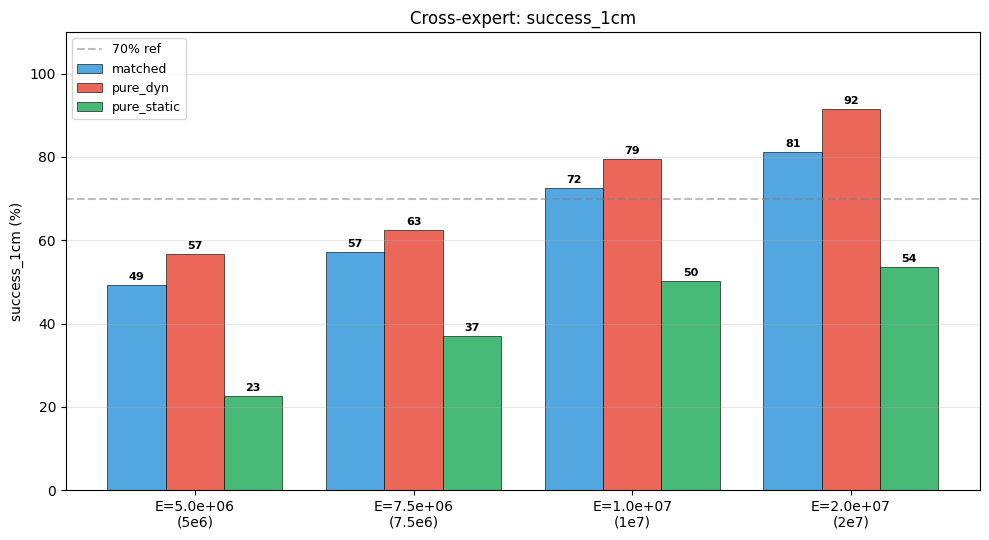

  → salvato in Evaluation_v2\_crossexpert\success_by_condition.png


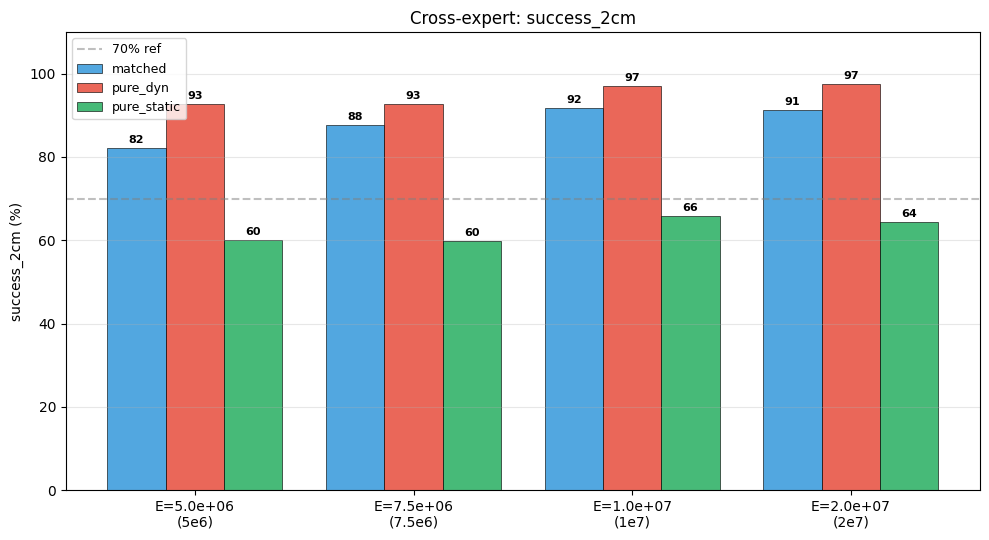

  → salvato in Evaluation_v2\_crossexpert\success_by_condition_2cm.png


In [21]:
def plot_success_by_condition(metric="success_1cm",
                              save_to=OUT_ROOT / "_crossexpert" / "success_by_condition.png"):
    """Grouped bar plot: success metric by (expert, condition)."""
    expert_names = list(EXPERTS.keys())
    cond_names   = list(EVAL_CONDITIONS.keys())
    cond_palette = {
        'matched':     '#3498db',
        'pure_dyn':    '#e74c3c',
        'pure_static': '#27ae60',
        'fast_dyn':    '#9b59b6',
        'slow_dyn':    '#f1c40f',
    }

    fig, ax = plt.subplots(figsize=(2.0 * len(expert_names) + 2, 5.5))
    x = np.arange(len(expert_names))
    w = 0.8 / max(len(cond_names), 1)

    for i, cond in enumerate(cond_names):
        vals = []
        for e in expert_names:
            r = all_results.get(e, {}).get(cond)
            if r is None:
                vals.append(np.nan)
            else:
                vals.append(r['summary']['overall'][metric])
        bars = ax.bar(x + (i - (len(cond_names)-1)/2) * w, vals, w,
                      label=cond, color=cond_palette.get(cond, None),
                      alpha=0.85, edgecolor='black', linewidth=0.5)
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width()/2, v + 1.2, f'{v:.0f}',
                        ha='center', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([f"E={EXPERTS[e]['E']:.1e}\n({e})" for e in expert_names])
    ax.set_ylabel(f'{metric} (%)')
    ax.set_title(f'Cross-expert: {metric}')
    ax.set_ylim(0, 110)
    ax.axhline(70, color='gray', ls='--', alpha=0.5, label='70% ref')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_to, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  → saved: {save_to}")


plot_success_by_condition('success_1cm')
plot_success_by_condition('success_2cm',
                          save_to=OUT_ROOT/'_crossexpert'/'success_by_condition_2cm.png')

### Static-vs-dynamic asymmetry within `matched`

For each expert, the success rate is decomposed into the static- and
dynamic-episode halves of the same `matched` run. This isolates the
anticipation bias from any distribution-shift confound: both bars come
from the same training-distribution sample, just filtered by episode
type.


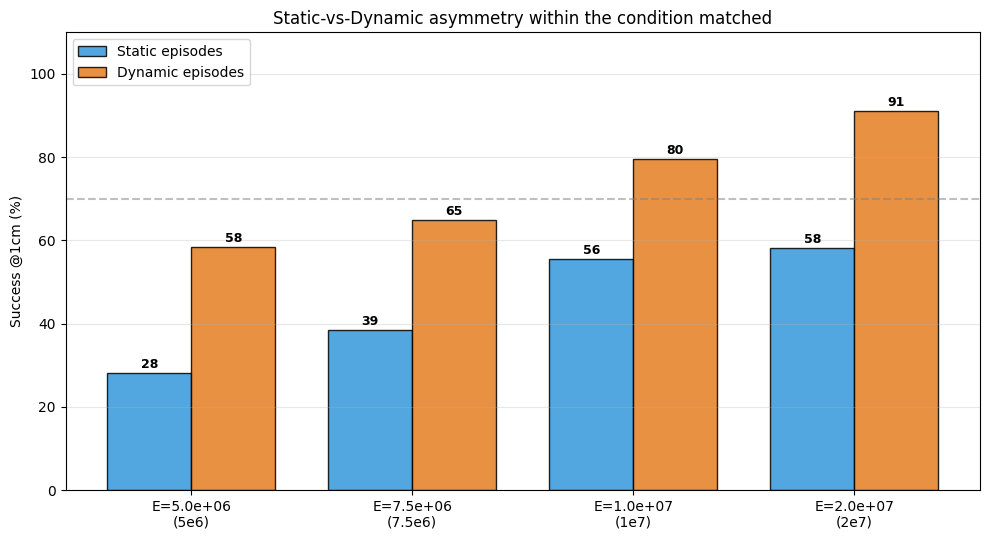

  → salvato in Evaluation_v2\_crossexpert\static_dyn_asymmetry.png


In [22]:
def plot_static_dynamic_asymmetry(condition="matched",
                                  save_to=OUT_ROOT / "_crossexpert" / "static_dyn_asymmetry.png"):
    """Within `condition`, plot @1cm decomposed into static vs dynamic episodes."""
    expert_names = list(EXPERTS.keys())
    succ_st  = [all_results.get(e, {}).get(condition, {})
                .get('summary', {}).get('static_only', {}).get('success_1cm', np.nan)
                for e in expert_names]
    succ_dy  = [all_results.get(e, {}).get(condition, {})
                .get('summary', {}).get('dynamic_only', {}).get('success_1cm', np.nan)
                for e in expert_names]

    fig, ax = plt.subplots(figsize=(2.0 * len(expert_names) + 2, 5.5))
    x = np.arange(len(expert_names))
    w = 0.38
    bars1 = ax.bar(x - w/2, succ_st, w, label='Static episodes',
                   color='#3498db', alpha=0.85, edgecolor='black')
    bars2 = ax.bar(x + w/2, succ_dy, w, label='Dynamic episodes',
                   color='#e67e22', alpha=0.85, edgecolor='black')
    for b, v in zip(bars1, succ_st):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v + 1.2, f'{v:.0f}',
                    ha='center', fontsize=9, fontweight='bold')
    for b, v in zip(bars2, succ_dy):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v + 1.2, f'{v:.0f}',
                    ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([f"E={EXPERTS[e]['E']:.1e}\n({e})" for e in expert_names])
    ax.set_ylabel('Success @1cm (%)')
    ax.set_title(f'Static-vs-Dynamic asymmetry within the condition {condition}')
    ax.set_ylim(0, 110)
    ax.axhline(70, color='gray', ls='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_to, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  → saved: {save_to}")


plot_static_dynamic_asymmetry('matched')

### Mean error over time per condition

One row per condition, one curve per expert. Useful to see whether all
experts converge at similar rates and whether the final steady-state
error matches across stiffness values.


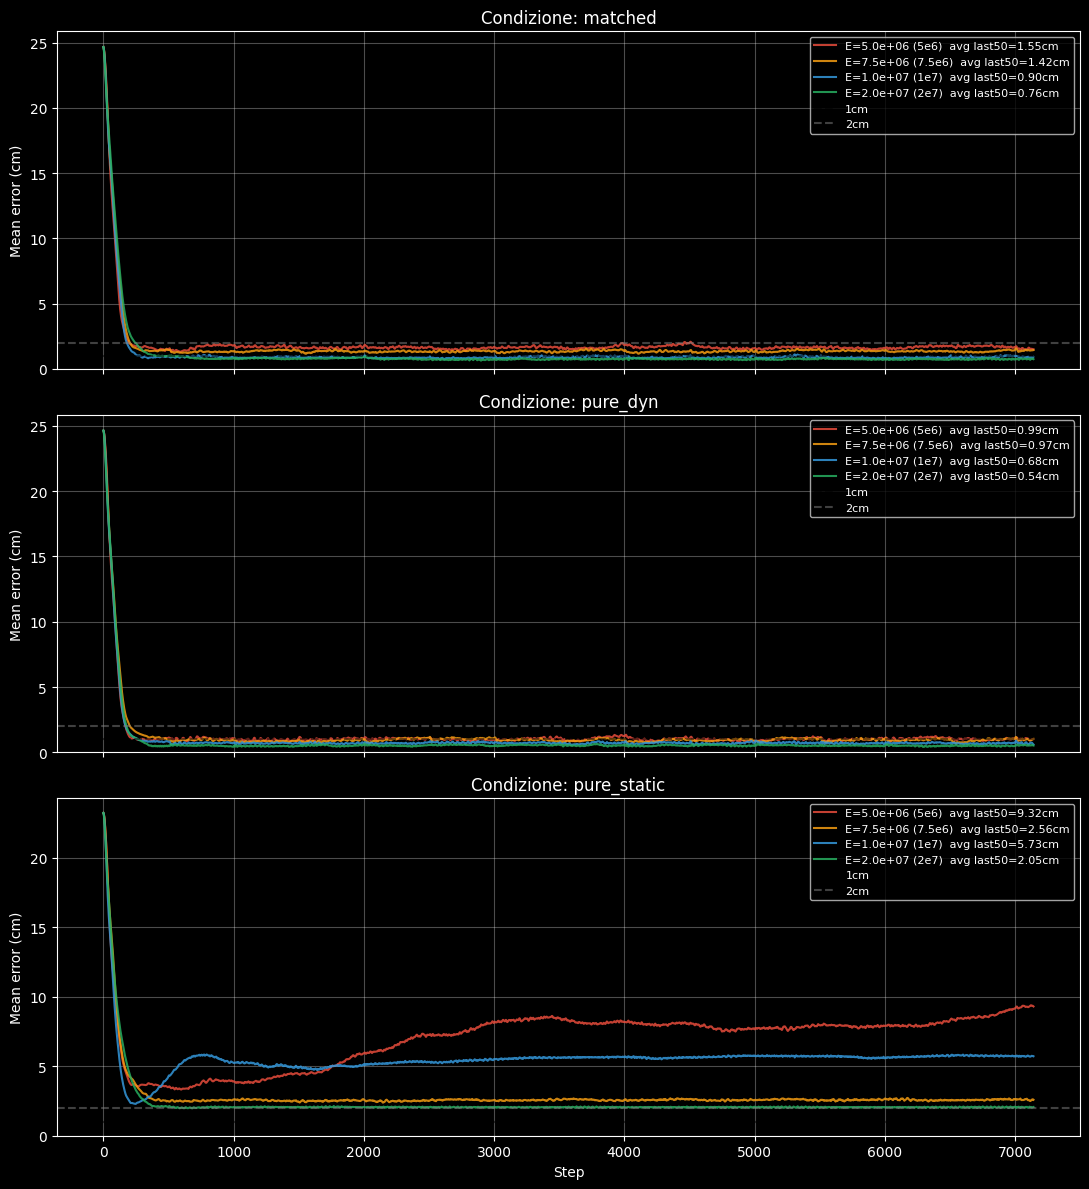

  → salvato in Evaluation_v2\_crossexpert\error_over_time.png


In [12]:
def plot_error_over_time_per_condition(save_to=OUT_ROOT/'_crossexpert'/'error_over_time.png'):
    palette = {'5e6':'#e74c3c', '7.5e6':'#f39c12', '1e7':'#3498db', '2e7':'#27ae60'}
    cond_names = list(EVAL_CONDITIONS.keys())
    fig, axes = plt.subplots(len(cond_names), 1,
                             figsize=(11, 4 * len(cond_names)),
                             sharex=True)
    if len(cond_names) == 1:
        axes = [axes]

    for ax, cond in zip(axes, cond_names):
        for e in EXPERTS:
            r = all_results.get(e, {}).get(cond)
            if r is None or 'step_data' not in r:
                continue
            df = r['step_data']
            err_step = df.groupby('step')['error'].mean() * 100
            ax.plot(err_step.index, err_step.values, lw=1.5,
                    color=palette.get(e, None), alpha=0.85,
                    label=f"E={EXPERTS[e]['E']:.1e} ({e})  "
                          f"avg last50={err_step.iloc[-50:].mean():.2f}cm")
        ax.axhline(1.0, color='black', ls='--', alpha=0.5, label='1cm')
        ax.axhline(2.0, color='gray',  ls='--', alpha=0.5, label='2cm')
        ax.set_ylabel('Mean error (cm)')
        ax.set_title(f'Condition: {cond}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, None)

    axes[-1].set_xlabel('Step')
    plt.tight_layout()
    plt.savefig(save_to, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  → saved: {save_to}")


plot_error_over_time_per_condition()

### Spatial diagnostic: position x expert heatmap

Only meaningful if `RUN_STATIC_DIAGNOSTIC=True`. Identifies workspace
dead zones: positions where one or more experts cannot reach the
target. Red cells = bad reach (low success), green = good.


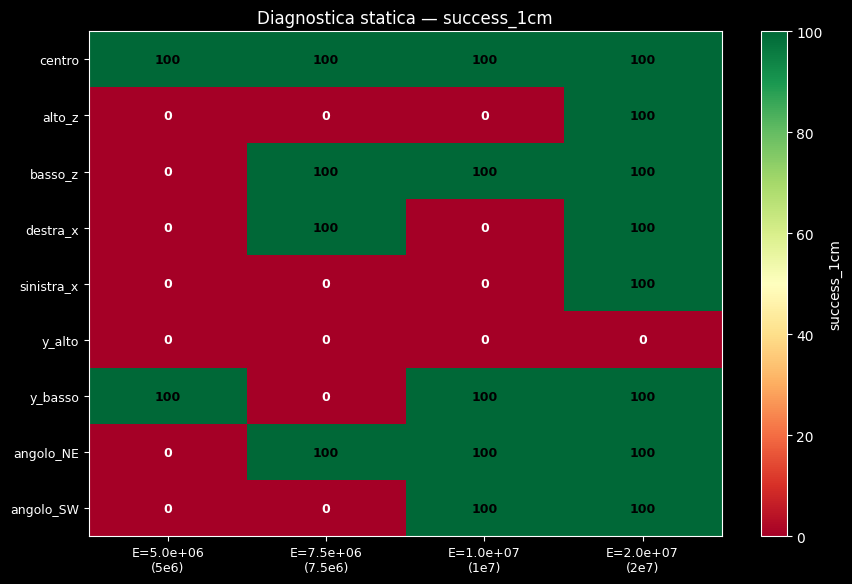

  → salvato in Evaluation_v2\_crossexpert\static_diag_heatmap.png


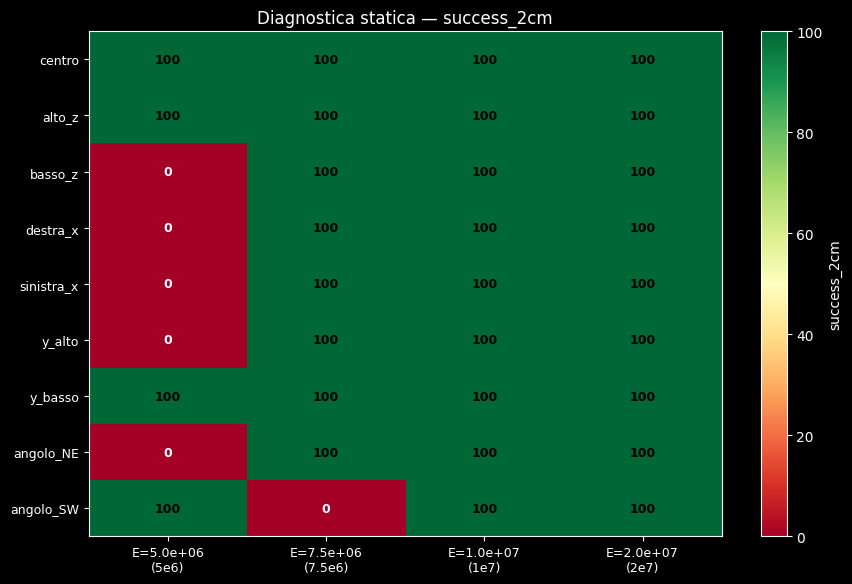

  → salvato in Evaluation_v2\_crossexpert\static_diag_heatmap_2cm.png


In [13]:
def plot_static_diagnostic_heatmap(metric="success_1cm",
                                   save_to=OUT_ROOT / "_crossexpert" / "static_diag_heatmap.png"):
    """Heatmap of per-position success across experts."""
    expert_names = [e for e in EXPERTS if all_results.get(e, {}).get('static_diagnostic')]
    if not expert_names:
        print("No experts have spatial diagnostic data.")
        return

    pos_names = list(STATIC_TEST_POSITIONS.keys())
    M = np.full((len(pos_names), len(expert_names)), np.nan)
    for j, e in enumerate(expert_names):
        per_pos = all_results[e]['static_diagnostic']['summary']['per_position_summary']
        for i, p in enumerate(pos_names):
            if p in per_pos:
                M[i, j] = per_pos[p][metric]

    fig, ax = plt.subplots(figsize=(1.5 * len(expert_names) + 3, 0.55 * len(pos_names) + 1))
    im = ax.imshow(M, aspect='auto', cmap='RdYlGn',
                   vmin=0 if metric.startswith('success') else None,
                   vmax=100 if metric.startswith('success') else None)
    ax.set_xticks(range(len(expert_names)))
    ax.set_xticklabels([f"E={EXPERTS[e]['E']:.1e}\n({e})" for e in expert_names],
                       fontsize=9)
    ax.set_yticks(range(len(pos_names)))
    ax.set_yticklabels(pos_names, fontsize=9)
    ax.set_title(f'Spatial diagnostic  — {metric}')
    fig.colorbar(im, ax=ax, label=metric)

    for i in range(len(pos_names)):
        for j in range(len(expert_names)):
            v = M[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha='center', va='center',
                        color='white' if v < 50 else 'black',
                        fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_to, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  → saved: {save_to}")


if RUN_STATIC_DIAGNOSTIC:
    plot_static_diagnostic_heatmap('success_1cm')
    plot_static_diagnostic_heatmap('success_2cm',
                                   save_to=OUT_ROOT/'_crossexpert'/'static_diag_heatmap_2cm.png')

## Per-expert deep dive

Set `INSPECT_EXPERT` and `INSPECT_CONDITION` below to produce detailed
plots for one specific (expert, condition) pair. Plots are saved under
`Evaluation/<expert>/_figures/`.


In [14]:
INSPECT_EXPERT    = list(EXPERTS.keys())[0]
INSPECT_CONDITION = "matched"

assert INSPECT_EXPERT in all_results
assert INSPECT_CONDITION in all_results[INSPECT_EXPERT], (
    f"Condition {INSPECT_CONDITION}  not evaluated for expert {INSPECT_EXPERT}")

inspect_res = all_results[INSPECT_EXPERT][INSPECT_CONDITION]
fig_dir     = OUT_ROOT / INSPECT_EXPERT / "_figures"
fig_dir.mkdir(exist_ok=True, parents=True)

print(f"Inspect: {INSPECT_EXPERT} / {INSPECT_CONDITION}")
print(f"  step_data : {len(inspect_res['step_data']):,} righe")
print(f"  episodi   : {inspect_res['step_data']['episode'].nunique()}")
print(f"  fig out   : {fig_dir}")

Inspect: 5e6 / matched
  step_data : 357,100 righe
  episodi   : 50
  fig out   : Evaluation_v2\5e6\_figures


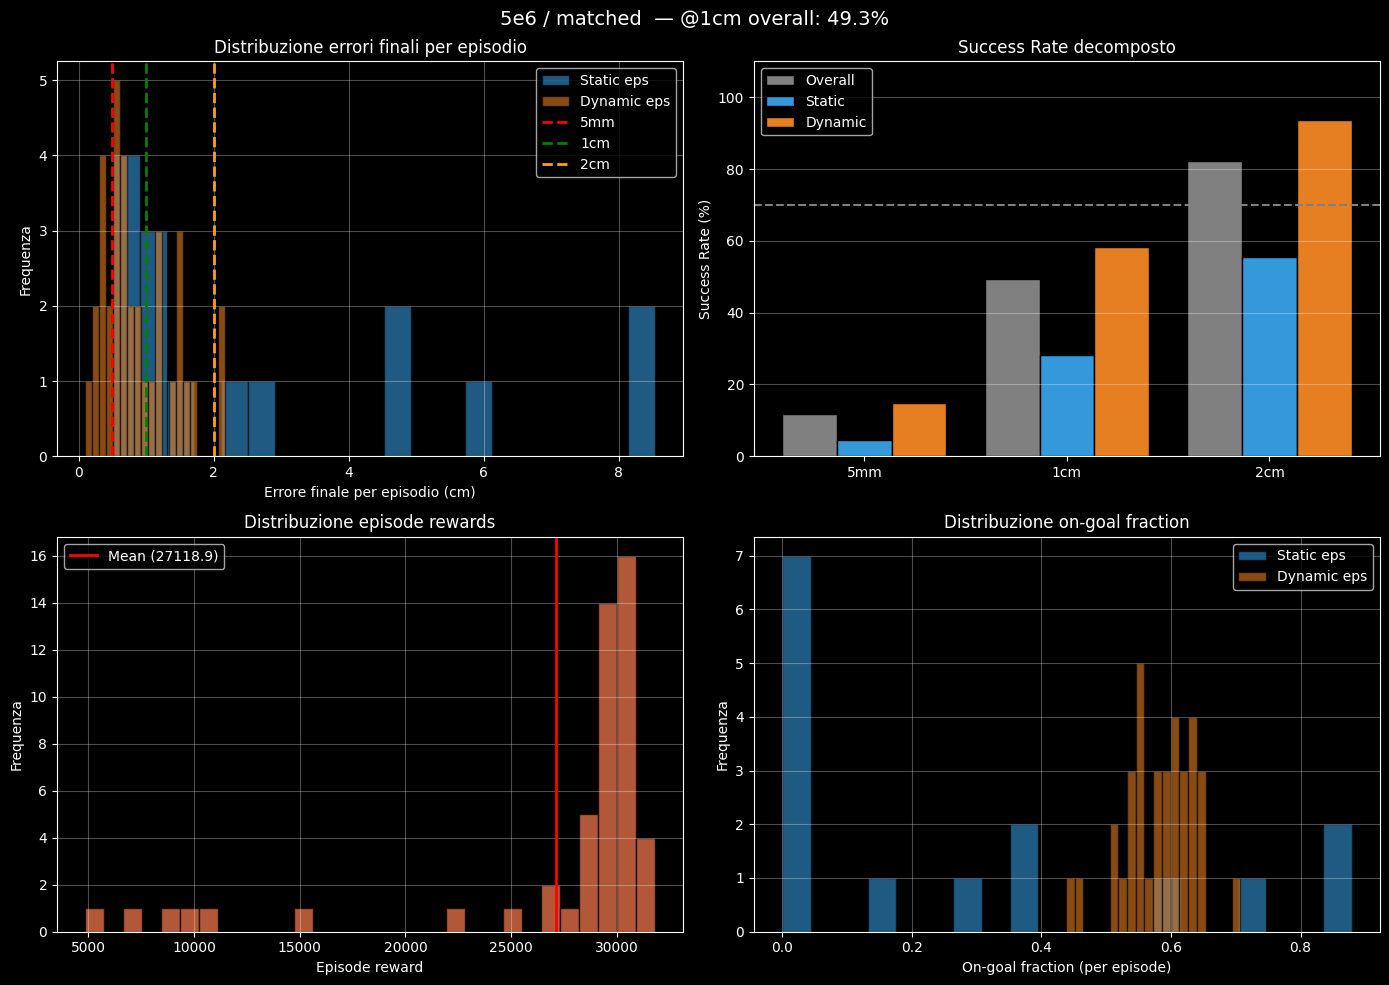

In [15]:
# Deep-dive panel 1: error distribution, success bars, reward histogram, on-goal histogram.
# Each split into static vs dynamic episodes when relevant.
df  = inspect_res['step_data']
pe  = inspect_res.get('per_episode')
if pe is None or len(pe) == 0:
    # fallback: compute from step_data
    pe = (df.groupby('episode')
            .agg(is_static=('episode_is_static', 'last'),
                 final_error_cm=('error', lambda x: x.iloc[-1] * 100),
                 mean_error_cm=('error', lambda x: x.mean() * 100))
            .reset_index())

s = inspect_res['summary']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Final error histogram, static vs dynamic
ax = axes[0, 0]
if pe['is_static'].any():
    ax.hist(pe[pe['is_static']]['final_error_cm'], bins=20,
            alpha=0.6, color='#3498db', edgecolor='black', label='Static eps')
if (~pe['is_static']).any():
    ax.hist(pe[~pe['is_static']]['final_error_cm'], bins=20,
            alpha=0.6, color='#e67e22', edgecolor='black', label='Dynamic eps')
for v, c, lbl in [(0.5, 'red', '5mm'), (1.0, 'green', '1cm'), (2.0, 'orange', '2cm')]:
    ax.axvline(v, color=c, ls='--', lw=2, label=lbl)
ax.set_xlabel('Final error per episode (cm)'); ax.set_ylabel('Frequency')
ax.set_title('Final error distribution')
ax.legend(); ax.grid(True, alpha=0.3)

# Success rates (overall + static + dynamic)
ax = axes[0, 1]
labels = ['5mm', '1cm', '2cm']
overall = [s['overall'][f'success_{t}'] for t in labels]
stat    = [s['static_only'].get(f'success_{t}', 0)   if s['static_only']  else 0 for t in labels]
dynm    = [s['dynamic_only'].get(f'success_{t}', 0)  if s['dynamic_only'] else 0 for t in labels]
x = np.arange(len(labels)); w = 0.27
ax.bar(x - w, overall, w, label='Overall', color='gray',     edgecolor='black')
ax.bar(x,     stat,    w, label='Static',  color='#3498db', edgecolor='black')
ax.bar(x + w, dynm,    w, label='Dynamic', color='#e67e22', edgecolor='black')
ax.axhline(70, color='gray', ls='--')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Success Rate (%)'); ax.set_ylim(0, 110)
ax.set_title('Success Rate decomposed')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Episode rewards
ax = axes[1, 0]
ax.hist(inspect_res['all_rewards'], bins=30, alpha=0.7, color='coral', edgecolor='black')
ax.axvline(np.mean(inspect_res['all_rewards']), color='red', lw=2,
           label=f'Mean ({np.mean(inspect_res["all_rewards"]):.1f})')
ax.set_xlabel('Episode reward'); ax.set_ylabel('Frequency')
ax.set_title('Episode reward distribution')
ax.legend(); ax.grid(True, alpha=0.3)

# On-goal fraction per episode
ax = axes[1, 1]
if 'on_goal_fraction' in pe.columns:
    pe_st = pe[pe['is_static']]
    pe_dy = pe[~pe['is_static']]
    ax.hist(pe_st['on_goal_fraction'], bins=20, alpha=0.6,
            color='#3498db', edgecolor='black', label='Static eps')
    ax.hist(pe_dy['on_goal_fraction'], bins=20, alpha=0.6,
            color='#e67e22', edgecolor='black', label='Dynamic eps')
    ax.set_xlabel('On-goal fraction (per episode)')
    ax.set_ylabel('Frequency')
    ax.set_title('On-goal fraction distribution')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'{INSPECT_EXPERT} / {INSPECT_CONDITION}  — '
             f"@1cm overall: {s['overall']['success_1cm']:.1f}%", fontsize=14)
plt.tight_layout()
plt.savefig(fig_dir / f'deepdive_{INSPECT_CONDITION}.png', dpi=150, bbox_inches='tight')
plt.show()

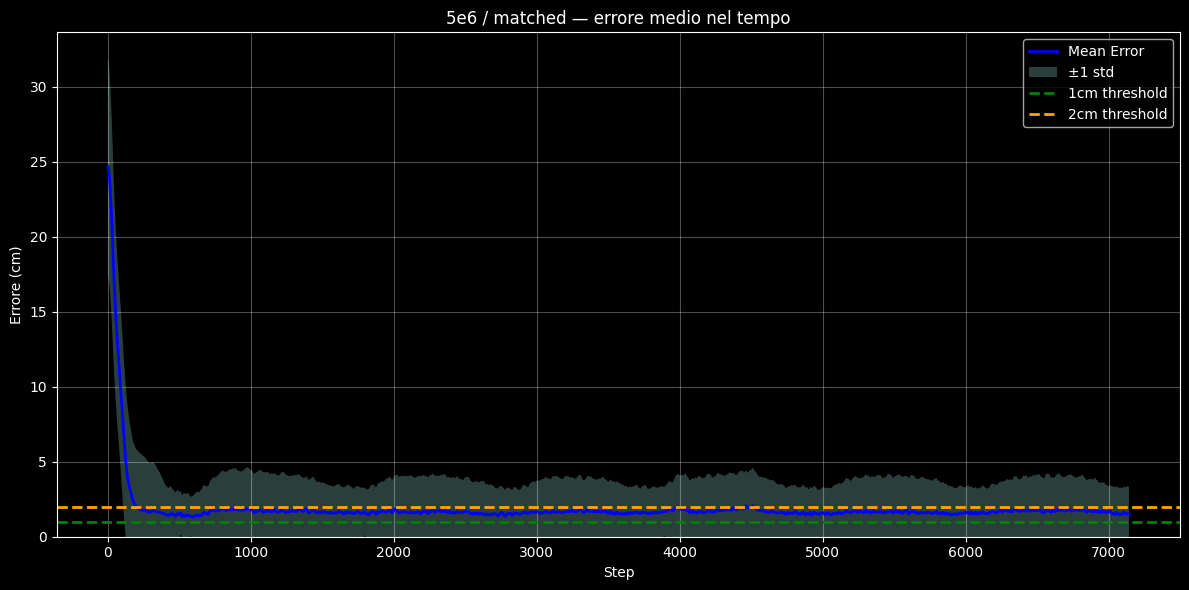


Final: 1.50 ± 1.81 cm
Min  : 1.29 cm @ step 594


In [16]:
# Deep-dive panel 2: mean error +/- std over time for the inspected (expert, condition).
df = inspect_res['step_data']
err_by_step = df.groupby('step')['error'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(12, 6))
mean_err = err_by_step['mean'] * 100
std_err  = err_by_step['std']  * 100
ax.plot(err_by_step.index, mean_err, 'b-', lw=2, label='Mean Error')
ax.fill_between(err_by_step.index, mean_err - std_err, mean_err + std_err,
                alpha=0.3, label='±1 std')
ax.axhline(1.0, color='g', ls='--', lw=2, label='1cm threshold')
ax.axhline(2.0, color='orange', ls='--', lw=2, label='2cm threshold')
ax.set_xlabel('Step'); ax.set_ylabel('Errore (cm)')
ax.set_title(f'{INSPECT_EXPERT} / {INSPECT_CONDITION} — mean error over time')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig(fig_dir / f'mean_error_{INSPECT_CONDITION}.png', dpi=150)
plt.show()
print(f"\nFinal: {mean_err.iloc[-1]:.2f} ± {std_err.iloc[-1]:.2f} cm")
print(f"Min  : {mean_err.min():.2f} cm @ step {mean_err.idxmin()}")

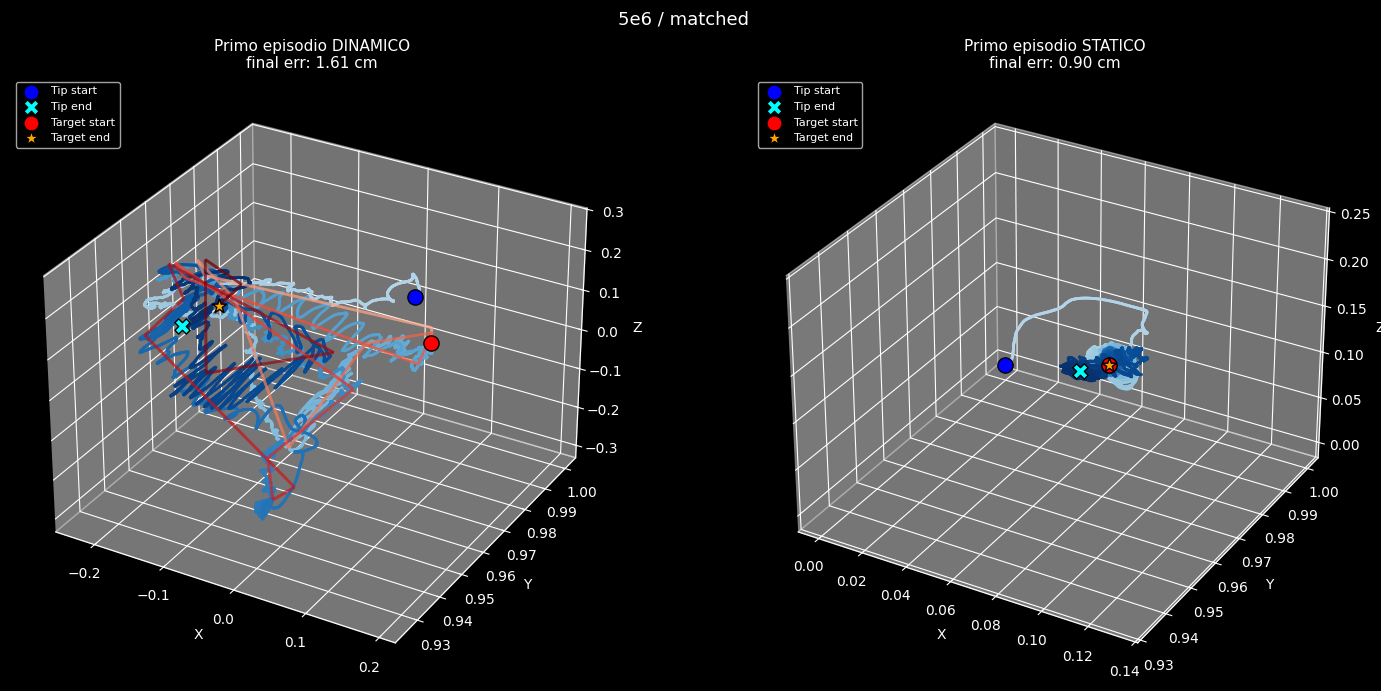

In [17]:
# Deep-dive panel 3: 3D trajectory of tip vs target for the first
# dynamic and first static episode (color graded over time).
fig = plt.figure(figsize=(15, 7))

for k_idx, (k_traj, k_target, title) in enumerate([
    ('example_traj_dyn',  'example_target_dyn',  'Primo episodio DINAMICO'),
    ('example_traj_stat', 'example_target_stat', 'Primo episodio STATICO'),
]):
    traj_data   = inspect_res.get(k_traj)
    target_data = inspect_res.get(k_target)
    if traj_data is None:
        continue

    traj   = np.array(traj_data)
    target = np.array(target_data)
    ax = fig.add_subplot(1, 2, k_idx + 1, projection='3d')

    # Tip path with gradient blue
    x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]
    for i in range(len(x) - 1):
        ax.plot(x[i:i+2], y[i:i+2], z[i:i+2],
                color=plt.cm.Blues(0.3 + 0.7 * i / max(len(x)-1, 1)), lw=2)

    # Target path with gradient red (dashed)
    tx, ty, tz = target[:, 0], target[:, 1], target[:, 2]
    for i in range(len(tx) - 1):
        ax.plot(tx[i:i+2], ty[i:i+2], tz[i:i+2],
                color=plt.cm.Reds(0.3 + 0.7 * i / max(len(tx)-1, 1)),
                lw=2, ls='--')

    ax.scatter(*traj[0],   c='blue',  s=120, marker='o', edgecolors='black', label='Tip start')
    ax.scatter(*traj[-1],  c='cyan',  s=120, marker='X', edgecolors='black', label='Tip end')
    ax.scatter(*target[0], c='red',   s=120, marker='o', edgecolors='black', label='Target start')
    ax.scatter(*target[-1],c='orange',s=120, marker='*', edgecolors='black', label='Target end')

    final_dist = np.linalg.norm(traj[-1] - target[-1])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'{title}\nfinal err: {final_dist*100:.2f} cm', fontsize=11)
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle(f'{INSPECT_EXPERT} / {INSPECT_CONDITION}', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / f'trajectory_3d_{INSPECT_CONDITION}.png', dpi=150, bbox_inches='tight')
plt.show()

## GIF rendering

Reconstructs a 3D animation of one episode from the saved step_data.
The `rod_positions` column carries the full Cosserat rod shape at each
step, which is what makes the GIF possible without re-running the
simulation. Parametric on (expert, condition, episode index).


In [18]:
def render_from_step_data(step_data_df, episode, save_gif, skip=10,
                           xlim=(-0.5, 0.5), ylim=(0.0, 1.2), zlim=(-0.5, 0.5)):
    """3D GIF of the rod tracking the target across one episode.

    Reads `rod_positions` (Cosserat rod shape, 3 x n_elem+1) at each
    step. `skip` controls frame downsampling (skip=10 -> 1 frame every
    10 steps).
    """
    ep = step_data_df[step_data_df['episode'] == episode].reset_index(drop=True)
    if len(ep) == 0:
        print(f"Episode {episode!r} not found")
        return
    if isinstance(ep['rod_positions'].iloc[0], str):
        import ast
        ep['rod_positions'] = ep['rod_positions'].apply(ast.literal_eval)

    frame_indices = list(range(0, len(ep), skip))
    fig = plt.figure(figsize=(10, 8))
    ax  = fig.add_subplot(111, projection='3d')

    def update(frame_num):
        i = frame_indices[frame_num]
        ax.clear()

        # Full rod shape at this step
        rod_pos = np.array(ep['rod_positions'].iloc[i])
        ax.plot(rod_pos[0], rod_pos[1], rod_pos[2],
                color='#8B7EC8', lw=6, solid_capstyle='round')

        # Target marker
        tgt = [ep['target_x'].iloc[i], ep['target_y'].iloc[i], ep['target_z'].iloc[i]]
        ax.scatter(*tgt, c='red', s=150, zorder=5)

        # Tip marker (end of rod)
        ax.scatter(rod_pos[0,-1], rod_pos[1,-1], rod_pos[2,-1],
                   c='green', s=80, zorder=5)

        # Recent trails for tip and target (last 150 steps).
        start = max(0, i - 150)
        ax.plot(ep['tip_pos_x'].values[start:i],
                ep['tip_pos_y'].values[start:i],
                ep['tip_pos_z'].values[start:i],
                'b-', alpha=0.3, lw=1)
        ax.plot(ep['target_x'].values[start:i],
                ep['target_y'].values[start:i],
                ep['target_z'].values[start:i],
                'r--', alpha=0.3, lw=1)

        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        dist  = ep['error'].iloc[i] * 100
        speed = ep['tip_speed'].iloc[i]
        ax.set_title(f'Step {i}/{len(ep)} | Err: {dist:.1f} cm | Speed: {speed:.2f} m/s')

    anim = FuncAnimation(fig, update, frames=len(frame_indices), interval=50)
    writer = PillowWriter(fps=20)
    pathlib.Path(save_gif).parent.mkdir(parents=True, exist_ok=True)
    anim.save(save_gif, writer=writer, dpi=80)
    plt.close()
    print(f"GIF saved: {save_gif}")


# Example: render the first episode of the inspected expert
render_from_step_data(
    inspect_res['step_data'],
    episode=0,
    save_gif=str(fig_dir / f"rod_3d_{INSPECT_CONDITION}_ep0.gif"),
    skip=10,
)

✅ GIF salvata: Evaluation_v2\5e6\_figures\rod_3d_matched_ep0.gif
